# Comprension_eda.ipynb

Analisis exploratorio y experimental del dataset de creditos para comprender calidad, estructura y comportamiento de las variables.
Este notebook deja trazadas reglas de validacion para etapas posteriores del pipeline.

## 1. Librerias y configuracion inicial
Cargamos librerias para analisis, visualizacion y manejo de datos.

In [2]:
# Manejo de rutas del proyecto
from pathlib import Path

# Manipulacion de datos tabulares
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos estilo de graficas para mejorar legibilidad
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Construimos la ruta al dataset ubicado en la raiz del proyecto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Base_de_datos.csv"

# Validamos existencia del archivo
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {DATA_PATH}")

# Mostramos la ruta efectiva para trazabilidad
print(f"Archivo fuente: {DATA_PATH}")

Archivo fuente: /Users/amaury/Library/Mobile Documents/com~apple~CloudDocs/henry/M5/mlops_pipeline/Base_de_datos.csv


## 2. Carga de datos y exploracion inicial
Leemos el CSV y revisamos primeras filas, forma general y tipos actuales.

In [3]:
# Cargamos dataset en un DataFrame base
df = pd.read_csv(DATA_PATH)

# Guardamos una copia cruda para comparar cambios durante la limpieza
df_raw = df.copy()

# Reportamos dimensiones globales
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

# Mostramos primeras observaciones para validar formato
display(df.head())

# Mostramos informacion estructural (tipo y no nulos)
display(df.info())

Filas: 10,763
Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,21/12/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,22/04/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,08/01/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,04/08/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,26/04/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  object 
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  object 
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null 

None

## 3. Caracterizacion de variables
Clasificamos columnas por tipo: numericas, categoricas, dicotomicas y de fecha.

In [4]:
# Detectamos columna objetivo esperada
target_candidates = ["Pago_atiempo", "pago_atiempo", "target", "y"]
target_col = next((c for c in target_candidates if c in df.columns), None)

# Validamos presencia de variable objetivo para analisis supervisado
if target_col is None:
    raise ValueError("No se encontro una columna objetivo (ej. Pago_atiempo).")

# Definimos columnas que por contexto deben ser fecha
date_cols = [c for c in ["fecha_prestamo"] if c in df.columns]

# Definimos columnas categoricas por negocio
business_categorical = ["tipo_laboral", "tendencia_ingresos"]
categorical_cols = [c for c in business_categorical if c in df.columns]

# Detectamos numericas inicialmente por inferencia de pandas
numeric_cols_initial = df.select_dtypes(include=[np.number]).columns.tolist()

# Marcamos dicotomicas (0/1) por cardinalidad para documentacion
dicotomic_cols = [
    c for c in df.columns
    if df[c].dropna().nunique() == 2 and set(df[c].dropna().unique()).issubset({0, 1})
]

# Columnas nominales/politomicas segun cardinalidad categorica
nominal_cols = [c for c in categorical_cols if df[c].dropna().nunique() <= 10]
polytomic_cols = [c for c in categorical_cols if df[c].dropna().nunique() > 10]

# Resumen de caracterizacion inicial
print(f"Variable objetivo: {target_col}")
print(f"Columnas de fecha: {date_cols}")
print(f"Categoricas por negocio: {categorical_cols}")
print(f"Dicotomicas detectadas: {dicotomic_cols}")
print(f"Nominales: {nominal_cols}")
print(f"Politomicas: {polytomic_cols}")
print(f"Numericas detectadas (inicial): {len(numeric_cols_initial)}")

Variable objetivo: Pago_atiempo
Columnas de fecha: ['fecha_prestamo']
Categoricas por negocio: ['tipo_laboral', 'tendencia_ingresos']
Dicotomicas detectadas: ['Pago_atiempo']
Nominales: ['tipo_laboral']
Politomicas: ['tendencia_ingresos']
Numericas detectadas (inicial): 20


## 4. Revision y unificacion de nulos
Unificamos diferentes representaciones de nulos para estandarizar calidad de datos.

In [5]:
# Definimos tokens comunes que representan ausencia de dato
null_tokens = ["", " ", "NA", "N/A", "null", "NULL", "None", "none", "nan", "NaN"]

# Reemplazamos esos tokens por np.nan en todas las columnas
df = df.replace(null_tokens, np.nan)

# Calculamos nulos por columna y porcentaje para priorizar tratamiento
null_count = df.isna().sum()
null_pct = (null_count / len(df) * 100).round(2)
null_report = pd.DataFrame({"nulos": null_count, "pct_nulos": null_pct}).sort_values("pct_nulos", ascending=False)

# Mostramos reporte consolidado de nulos
display(null_report)

,nulos,pct_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_total,156,1.45
saldo_mora,156,1.45
puntaje_datacredito,6,0.06
tipo_credito,0,0.00
huella_consulta,0,0.00
creditos_sectorReal,0,0.00


## 5. Eliminacion de variables irrelevantes (si aplica)
Aplicamos una regla objetiva para remover columnas sin informacion util (constantes o casi vacias).

In [6]:
# Identificamos columnas constantes (sin variacion)
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

# Identificamos columnas con mas de 95% de nulos
high_null_cols = null_report[null_report["pct_nulos"] > 95].index.tolist()

# Unimos criterios de irrelevancia, excluyendo explicitamente la variable objetivo
irrelevant_cols = sorted(set(constant_cols + high_null_cols) - {target_col})

# Eliminamos columnas irrelevantes si existen
if irrelevant_cols:
    df = df.drop(columns=irrelevant_cols)

# Reportamos resultado del filtro
print(f"Columnas eliminadas por irrelevancia: {irrelevant_cols}")
print(f"Total columnas despues del filtro: {df.shape[1]}")

Columnas eliminadas por irrelevancia: []
Total columnas despues del filtro: 23


## 6. Conversion de tipos y correcciones
Convertimos cada columna a su tipo correcto para que cada campo tenga representacion uniforme.

In [7]:
# Convertimos la fecha con formato dia/mes/anio y hora
if "fecha_prestamo" in df.columns:
    df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], dayfirst=True, errors="coerce")

# Definimos columnas esperadas como numericas segun diccionario del negocio
expected_numeric = [
    "tipo_credito", "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
    target_col
]

# Convertimos de forma segura a numerico donde corresponda
for col in expected_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convertimos columnas categoricas conocidas
for col in ["tipo_laboral", "tendencia_ingresos"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Convertimos objetivo a entero nullable para conservar nulos si existen
if target_col in df.columns:
    df[target_col] = df[target_col].astype("Int64")

# Mostramos tipos finales para validar consistencia
display(df.dtypes.to_frame(name="dtype"))

/var/folders/mp/vzvjst7x3977pdrswq__5cyw0000gn/T/ipykernel_72863/2175948109.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], dayfirst=True, errors="coerce")


,dtype
tipo_credito,int64
fecha_prestamo,datetime64[ns]
capital_prestado,int64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,category
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


## 7. Descripcion estadistica y analisis univariable
Aplicamos `describe()` y metricas extendidas para variables numericas y categoricas.

In [8]:
# Extraemos listas finales por tipo tras conversion
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols_final = df.select_dtypes(include=["category", "object", "bool"]).columns.tolist()

# Mostramos describe de variables numericas
display(df[numeric_cols].describe().T)

# Mostramos describe de variables categoricas cuando existan
if categorical_cols_final:
    display(df[categorical_cols_final].describe().T)

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131,2.338279,4.0,4.0,4.0,9.0,68.0
capital_prestado,10763.0,2434314.99712,1909642.757024,360000.0,1224831.0,1921920.0,3084840.0,41444153.0
plazo_meses,10763.0,10.575583,6.632082,2.0,6.0,10.0,12.0,90.0
edad_cliente,10763.0,43.94862,15.060877,19.0,33.0,42.0,53.0,123.0
salario_cliente,10763.0,17216431.459909,355476717.603482,0.0,2000000.0,3000000.0,4875808.0,22000000000.0
total_otros_prestamos,10763.0,6238869.648518,118418316.941069,0.0,500000.0,1000000.0,2000000.0,6787675263.0
cuota_pactada,10763.0,243617.406671,210493.694608,23944.0,121041.5,182863.0,287833.5,3816752.0
puntaje,10763.0,91.170036,16.465441,-38.00999,95.227787,95.227787,95.227787,95.227787
puntaje_datacredito,10757.0,780.790834,104.878031,-7.0,757.0,791.0,825.0,999.0
cant_creditosvigentes,10763.0,5.726749,3.977162,0.0,3.0,5.0,8.0,62.0


,count,unique,top,freq
tipo_laboral,10763,2,Empleado,6754
tendencia_ingresos,7831,46,Creciente,5294


In [9]:
# Construimos tabla de metricas univariables extendidas para numericas
stats_rows = []
for col in numeric_cols:
    # Omitimos columnas completamente vacias
    s = df[col].dropna()
    if s.empty:
        continue

    # Calculamos metricas de tendencia central, dispersion y forma
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    stats_rows.append({
        "variable": col,
        "media": s.mean(),
        "mediana": s.median(),
        "moda": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "min": s.min(),
        "max": s.max(),
        "rango": s.max() - s.min(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "varianza": s.var(),
        "desv_std": s.std(),
        "skewness": s.skew(),
        "kurtosis": s.kurt(),
    })

# Consolidamos en DataFrame para lectura analitica
stats_df = pd.DataFrame(stats_rows).set_index("variable").sort_index()
display(stats_df)

# Clasificamos tipo de distribucion de forma aproximada usando skewness
def classify_distribution(skew_value: float) -> str:
    # Regla simple para orientar interpretacion inicial
    if pd.isna(skew_value):
        return "indeterminada"
    if abs(skew_value) < 0.5:
        return "aprox_simetrica"
    if skew_value >= 0.5:
        return "sesgo_positivo"
    return "sesgo_negativo"

distribution_map = stats_df[["skewness"]].copy()
distribution_map["tipo_distribucion_aprox"] = distribution_map["skewness"].apply(classify_distribution)
display(distribution_map)

,media,mediana,moda,min,max,rango,q1,q3,iqr,varianza,desv_std,skewness,kurtosis
variable,,,,,,,,,,,,,
Pago_atiempo,9.525225e-01,1.000000e+00,1.000000e+00,0.00000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.00,4.522756e-02,2.126677e-01,-4.256468,16.120512
cant_creditosvigentes,5.726749e+00,5.000000e+00,4.000000e+00,0.00000,6.200000e+01,6.200000e+01,3.000000e+00,8.000000e+00,5.00,1.581782e+01,3.977162e+00,1.797738,8.623346
capital_prestado,2.434315e+06,1.921920e+06,1.200000e+06,360000.00000,4.144415e+07,4.108415e+07,1.224831e+06,3.084840e+06,1860009.00,3.646735e+12,1.909643e+06,3.723884,35.318093
creditos_sectorCooperativo,2.698132e-01,0.000000e+00,0.000000e+00,0.00000,1.300000e+01,1.300000e+01,0.000000e+00,0.000000e+00,0.00,5.133305e-01,7.164708e-01,4.218667,29.351455
creditos_sectorFinanciero,2.779987e+00,2.000000e+00,1.000000e+00,0.00000,5.100000e+01,5.100000e+01,1.000000e+00,4.000000e+00,3.00,7.555938e+00,2.748807e+00,2.703071,19.441771
creditos_sectorReal,1.302704e+00,1.000000e+00,0.000000e+00,0.00000,2.500000e+01,2.500000e+01,0.000000e+00,2.000000e+00,2.00,3.328544e+00,1.824430e+00,3.164866,18.187208
cuota_pactada,2.436174e+05,1.828630e+05,2.059900e+05,23944.00000,3.816752e+06,3.792808e+06,1.210415e+05,2.878335e+05,166792.00,4.430760e+10,2.104937e+05,3.793301,26.650757
edad_cliente,4.394862e+01,4.200000e+01,4.000000e+01,19.00000,1.230000e+02,1.040000e+02,3.300000e+01,5.300000e+01,20.00,2.268300e+02,1.506088e+01,1.934399,7.868936
huella_consulta,4.228561e+00,4.000000e+00,2.000000e+00,0.00000,2.900000e+01,2.900000e+01,2.000000e+00,6.000000e+00,4.00,9.392282e+00,3.064683e+00,1.487102,3.998984


,skewness,tipo_distribucion_aprox
variable,,
Pago_atiempo,-4.256468,sesgo_negativo
cant_creditosvigentes,1.797738,sesgo_positivo
capital_prestado,3.723884,sesgo_positivo
creditos_sectorCooperativo,4.218667,sesgo_positivo
creditos_sectorFinanciero,2.703071,sesgo_positivo
creditos_sectorReal,3.164866,sesgo_positivo
cuota_pactada,3.793301,sesgo_positivo
edad_cliente,1.934399,sesgo_positivo
huella_consulta,1.487102,sesgo_positivo


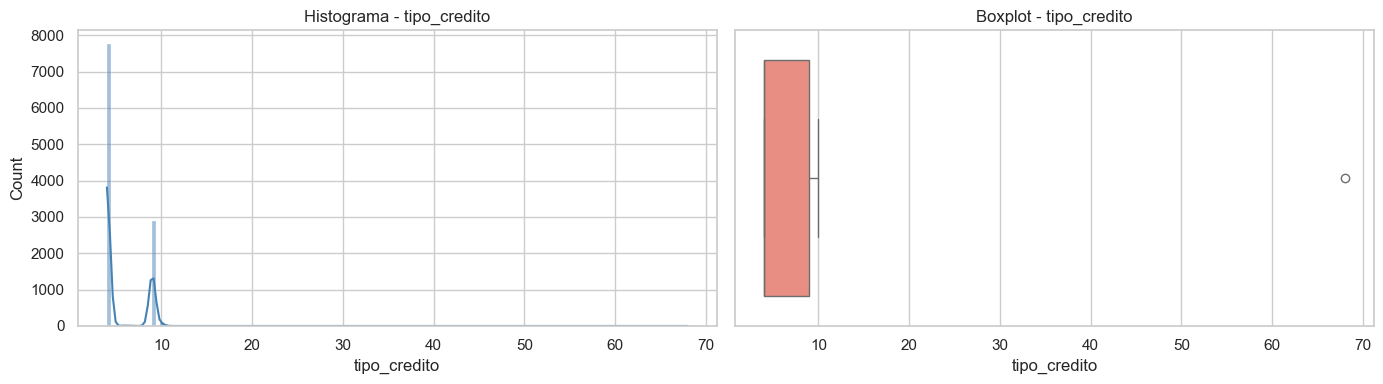

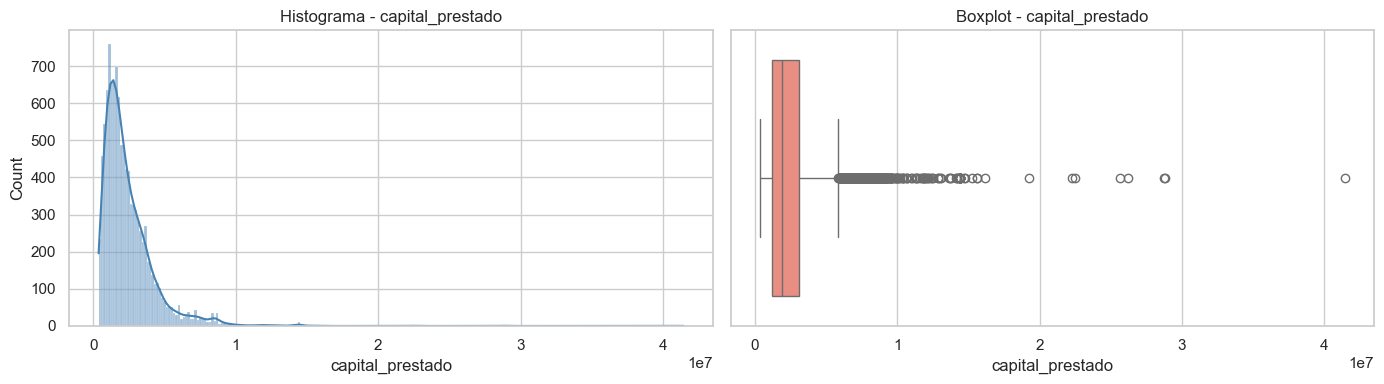

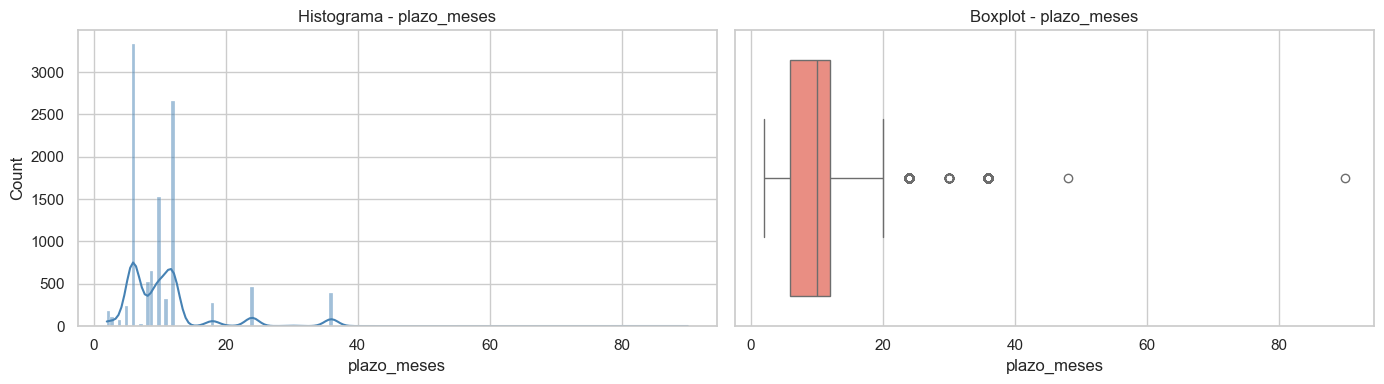

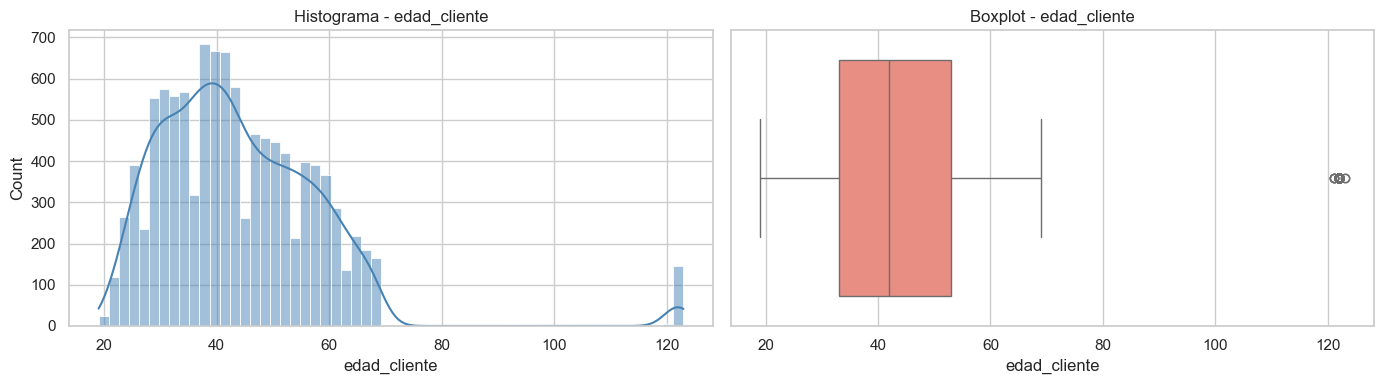

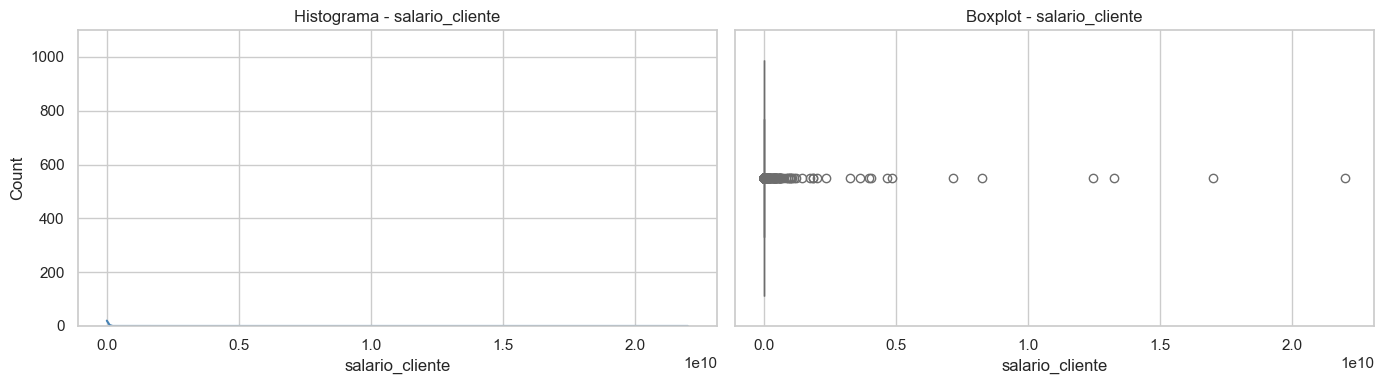

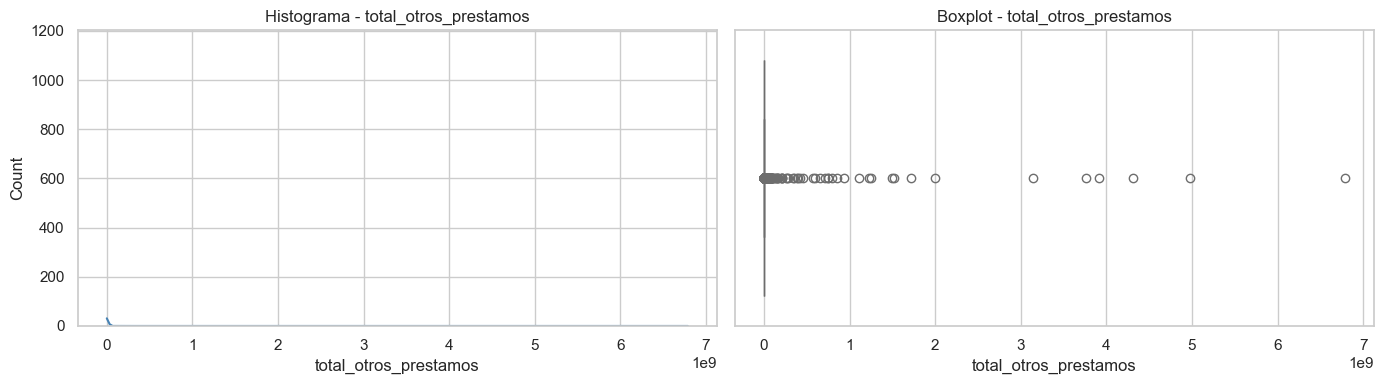

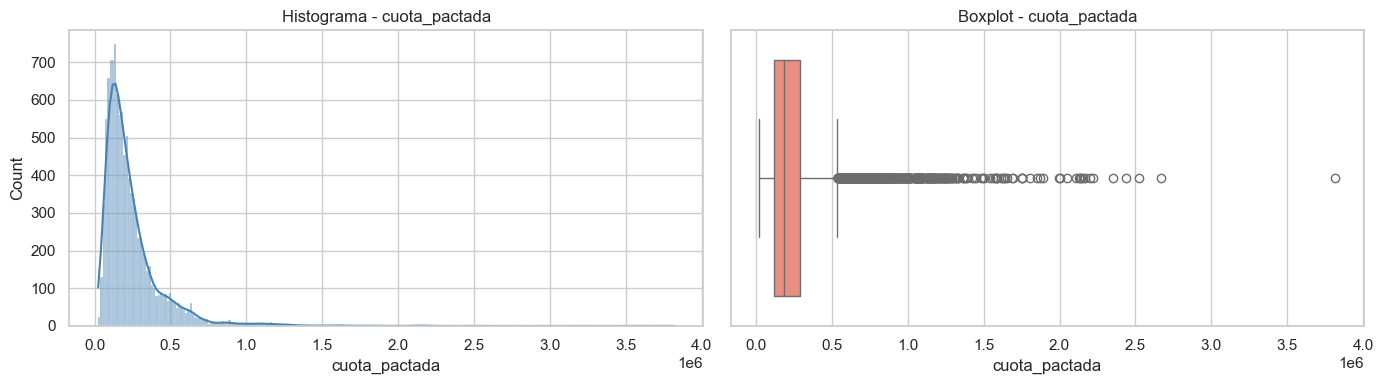

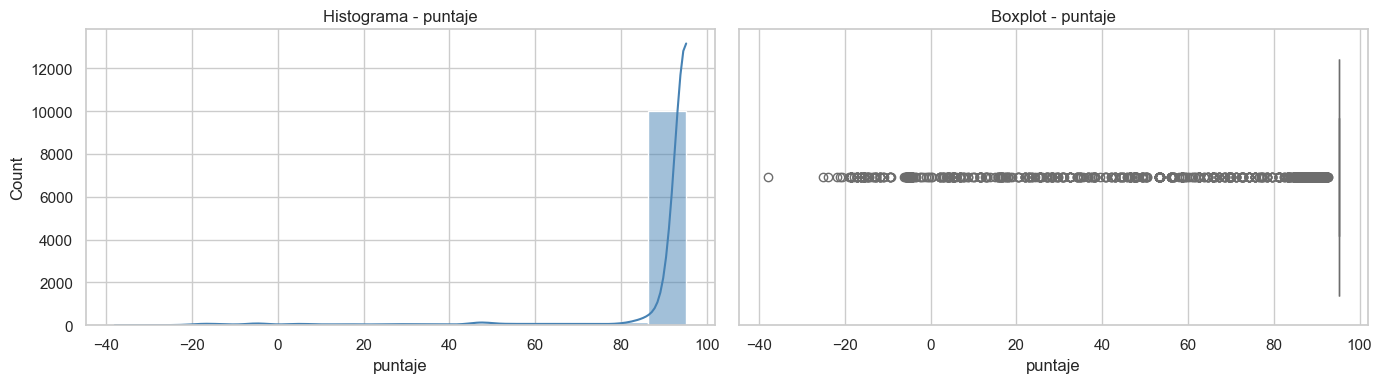

In [10]:
# Seleccionamos un subconjunto de numericas para visualizacion clara
plot_numeric_cols = [c for c in numeric_cols if c != target_col][:8]

# Graficamos histogramas para distribucion
for col in plot_numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma con densidad
    sns.histplot(df[col], kde=True, ax=ax[0], color="steelblue")
    ax[0].set_title(f"Histograma - {col}")

    # Boxplot para detectar dispersion y posibles outliers
    sns.boxplot(x=df[col], ax=ax[1], color="salmon")
    ax[1].set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()


Variable categorica: tipo_laboral


,conteo,porcentaje
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25


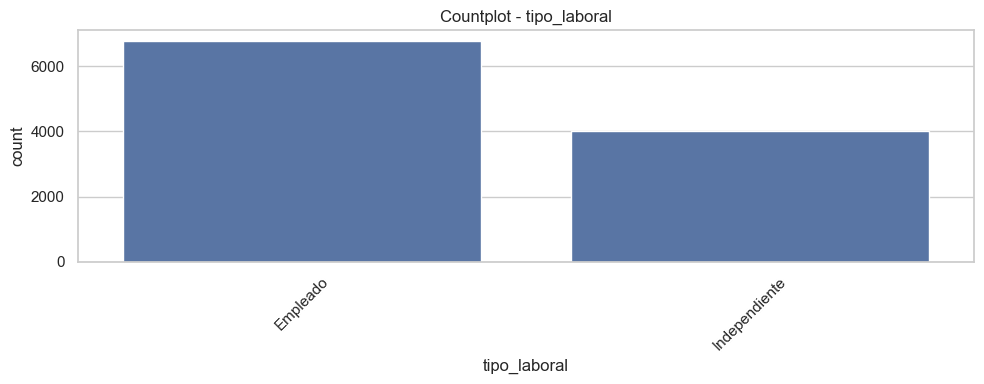


Variable categorica: tendencia_ingresos


,conteo,porcentaje
tendencia_ingresos,,
Creciente,5294,49.19
NaN,2932,27.24
Decreciente,1291,11.99
Estable,1188,11.04
0,7,0.07
8315,6,0.06
1000000,4,0.04
9147,2,0.02
54683,1,0.01


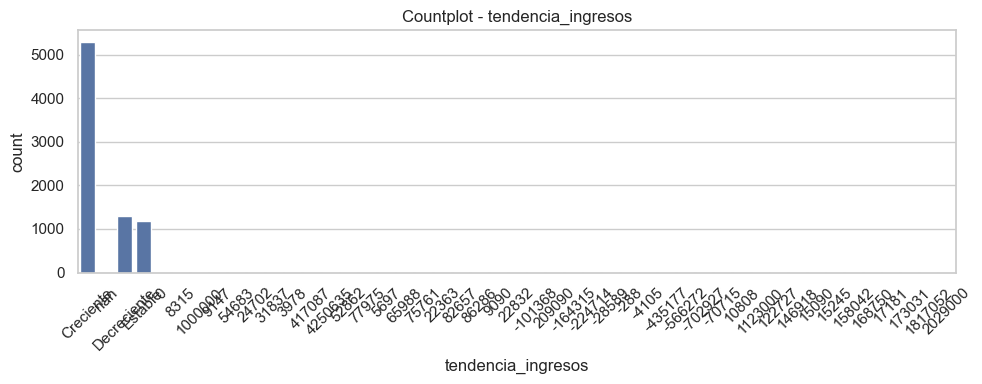

In [11]:
# Exploramos categoricas con conteos y tablas de frecuencia
for col in categorical_cols_final:
    print(f"\nVariable categorica: {col}")

    # Tabla de frecuencias absolutas y relativas
    freq = df[col].value_counts(dropna=False)
    freq_pct = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    display(pd.DataFrame({"conteo": freq, "porcentaje": freq_pct}))

    # Grafico de conteos
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts(dropna=False).index)
    plt.title(f"Countplot - {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Analisis bivariable frente a la variable objetivo
Relacionamos variables numericas y categoricas respecto al objetivo para identificar patrones de riesgo.

,cant_creditosvigentes,capital_prestado,creditos_sectorCooperativo,creditos_sectorFinanciero,creditos_sectorReal,cuota_pactada,edad_cliente,huella_consulta,plazo_meses,promedio_ingresos_datacredito,puntaje,puntaje_datacredito,salario_cliente,saldo_mora,saldo_mora_codeudor,saldo_principal,saldo_total,tipo_credito,total_otros_prestamos
Pago_atiempo,,,,,,,,,,,,,,,,,,,
0,5.569472,2.781774e+06,0.201566,2.516634,1.493151,254755.690802,41.772994,5.240705,12.450098,1.605742e+06,23.091216,748.880392,2.355514e+07,82.368000,0.000000,36646.427386,39074.922000,5.401174,1.156440e+07
1,5.734588,2.416996e+06,0.273215,2.793114,1.293211,243062.230784,44.057062,4.178112,10.482150,2.023448e+06,94.563352,782.379038,1.690049e+07,4.054418,0.272624,40526.734710,46276.899871,5.411627,5.973424e+06


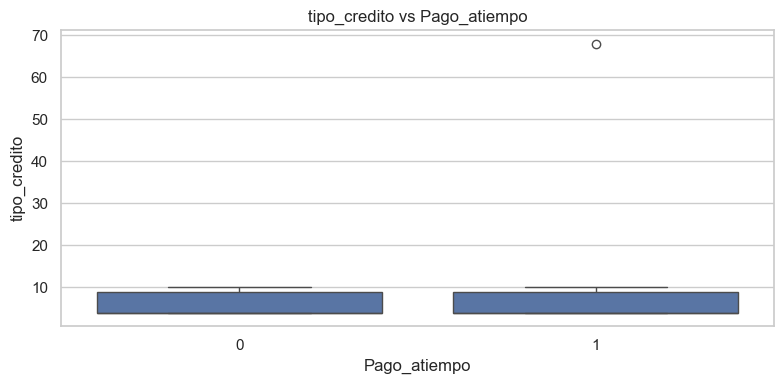

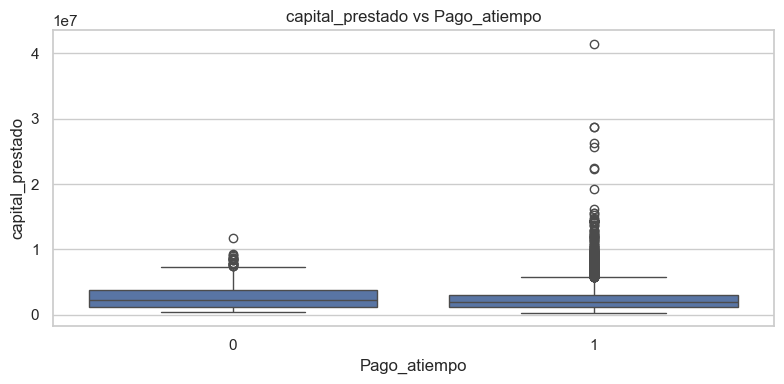

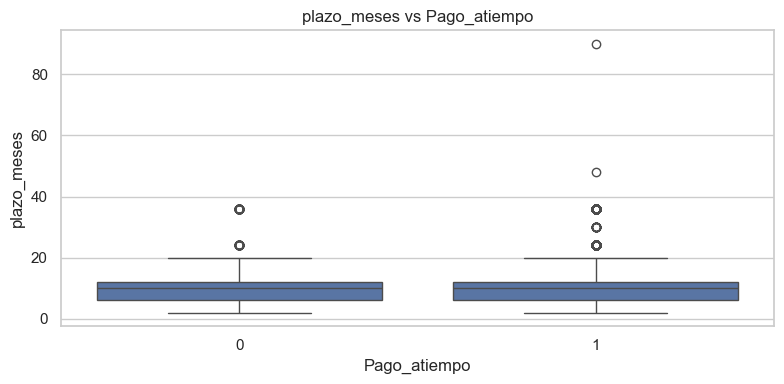

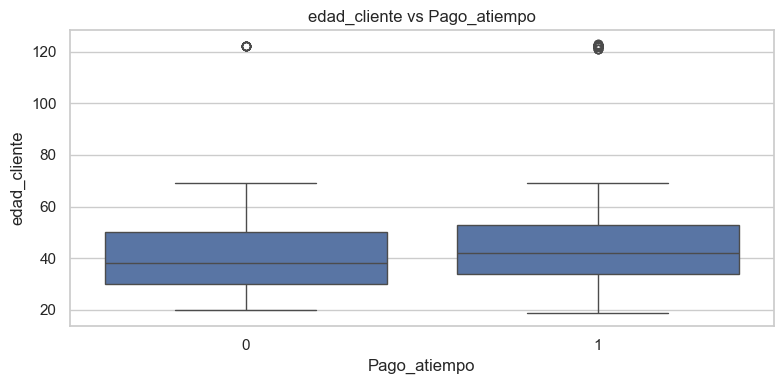

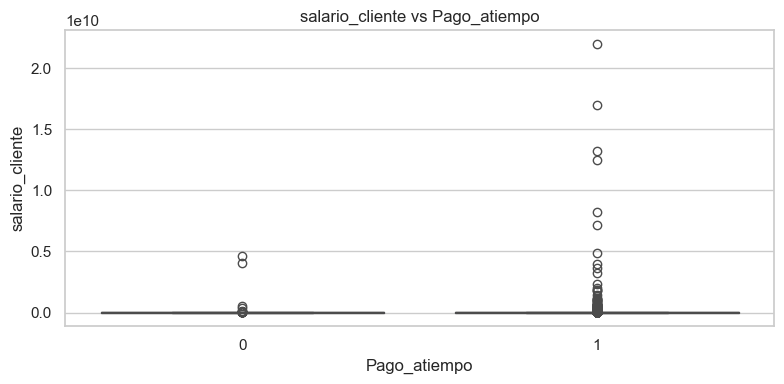

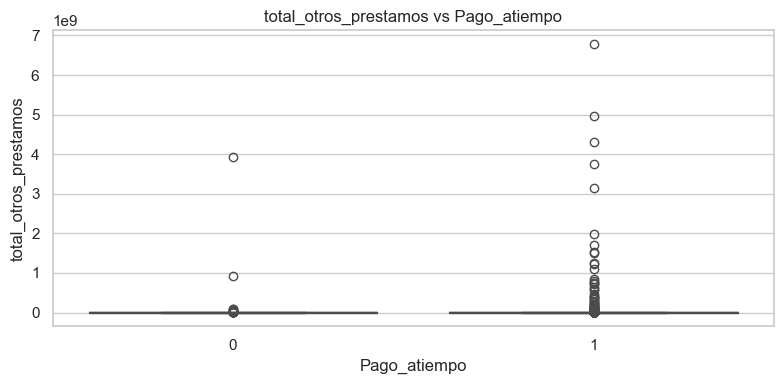

In [12]:
# Definimos solo registros con objetivo no nulo para analisis supervisado
df_supervised = df[df[target_col].notna()].copy()

# Tabla pivote de medias numericas por clase objetivo
numeric_without_target = [c for c in numeric_cols if c != target_col]
pivot_mean = df_supervised.pivot_table(values=numeric_without_target, index=target_col, aggfunc="mean")
display(pivot_mean)

# Boxplots por objetivo para un subconjunto de variables numericas
for col in numeric_without_target[:6]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_supervised, x=target_col, y=col)
    plt.title(f"{col} vs {target_col}")
    plt.tight_layout()
    plt.show()


Tabla cruzada normalizada: tipo_laboral vs Pago_atiempo


Pago_atiempo,0,1
tipo_laboral,,
Empleado,0.043,0.957
Independiente,0.055,0.945


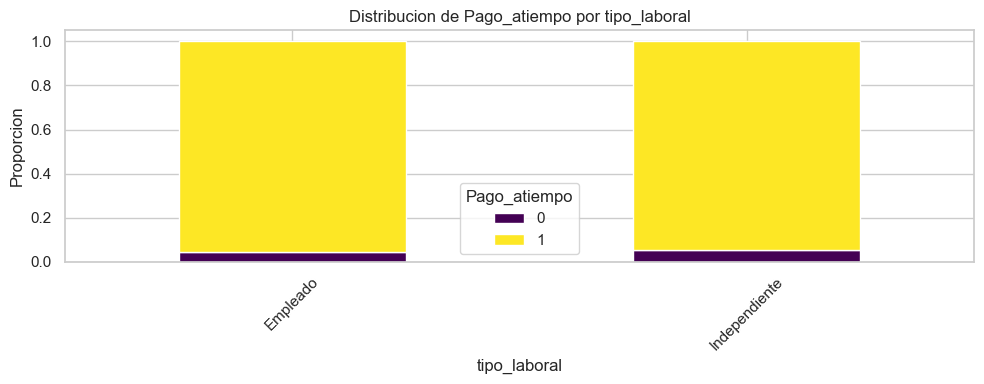


Tabla cruzada normalizada: tendencia_ingresos vs Pago_atiempo


Pago_atiempo,0,1
tendencia_ingresos,,
-101368,0.000,1.000
-164315,0.000,1.000
-224714,0.000,1.000
-28589,0.000,1.000
-288,0.000,1.000
-4105,0.000,1.000
-435177,0.000,1.000
-566272,0.000,1.000
-702927,0.000,1.000


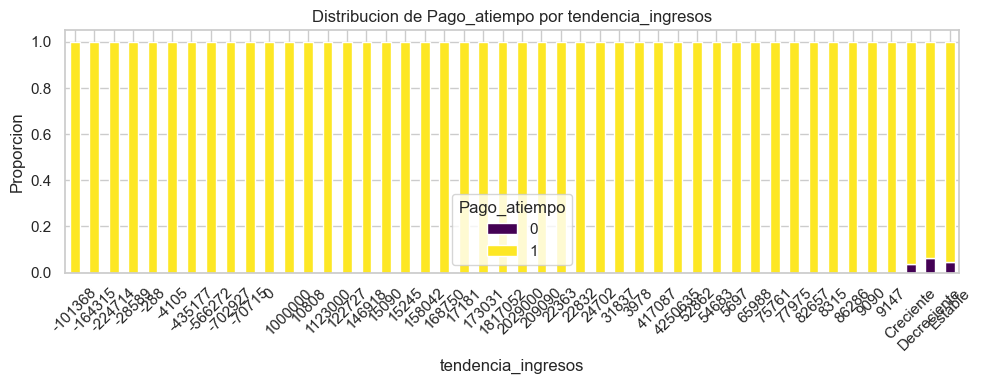

In [13]:
# Analisis categorico contra objetivo con tablas cruzadas normalizadas
for col in categorical_cols_final:
    # Construimos tabla cruzada (porcentaje por categoria)
    ct = pd.crosstab(df_supervised[col], df_supervised[target_col], normalize="index").round(3)
    print(f"\nTabla cruzada normalizada: {col} vs {target_col}")
    display(ct)

    # Graficamos barras apiladas para facilitar comparacion visual
    ct.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="viridis")
    plt.title(f"Distribucion de {target_col} por {col}")
    plt.ylabel("Proporcion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Analisis multivariable
Revisamos relaciones simultaneas entre variables para detectar redundancia y estructuras de dependencia.

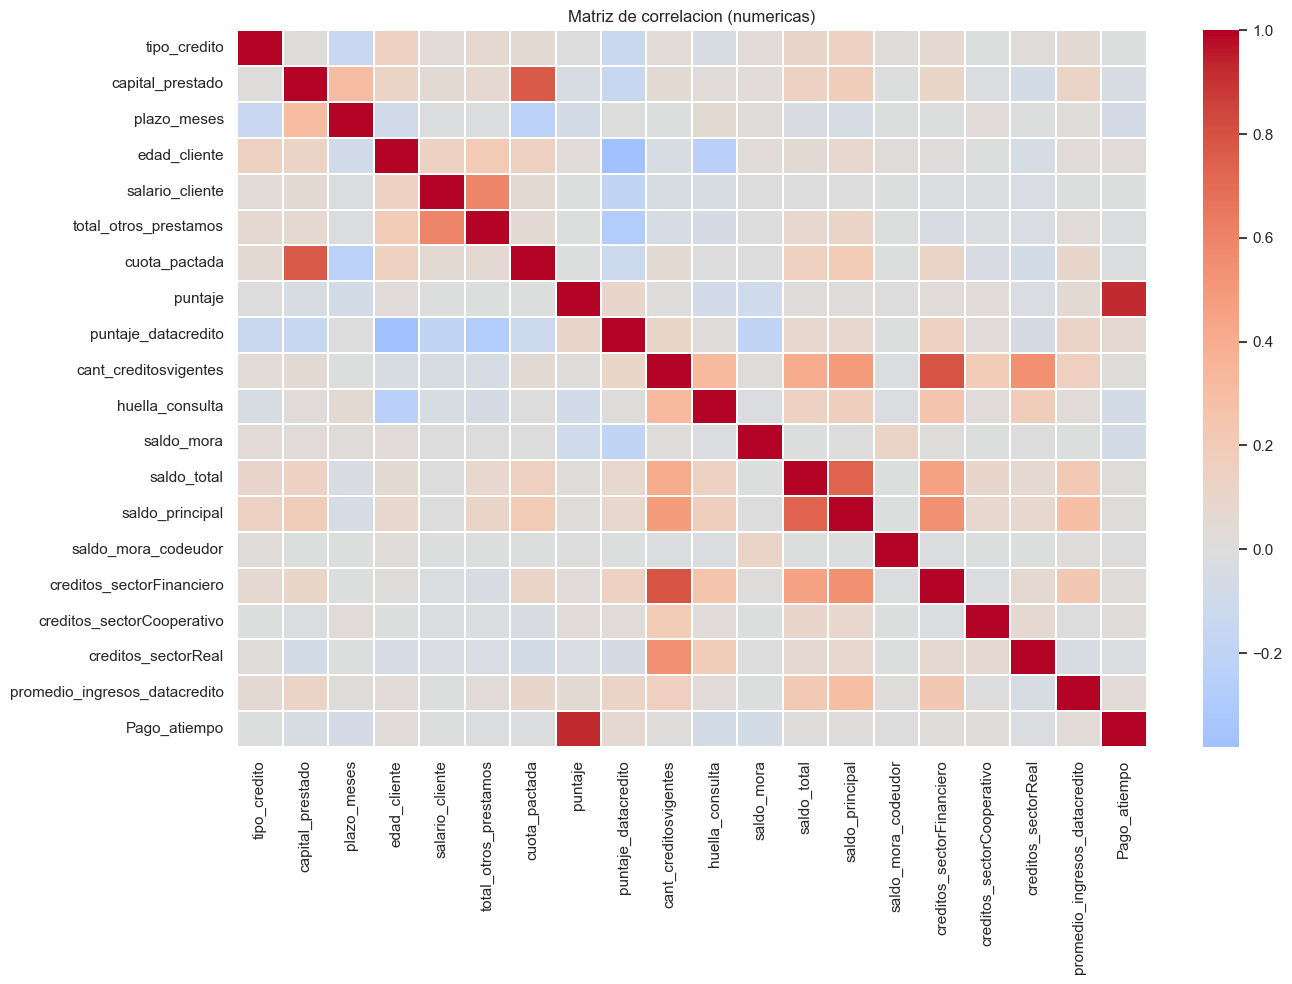

,var_1,var_2,corr,abs_corr
123,puntaje,Pago_atiempo,0.923134,0.923134
140,cant_creditosvigentes,creditos_sectorFinanciero,0.791253,0.791253
23,capital_prestado,cuota_pactada,0.764104,0.764104
162,saldo_total,saldo_principal,0.734664,0.734664


In [14]:
# Calculamos matriz de correlacion para variables numericas
corr = df[numeric_cols].corr(numeric_only=True)

# Graficamos heatmap para identificar relaciones lineales fuertes
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Matriz de correlacion (numericas)")
plt.tight_layout()
plt.show()

# Mostramos pares con correlacion alta en valor absoluto
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var_1", "level_1": "var_2", 0: "corr"})
    .assign(abs_corr=lambda x: x["corr"].abs())
    .query("abs_corr >= 0.7")
    .sort_values("abs_corr", ascending=False)
)
display(high_corr_pairs)

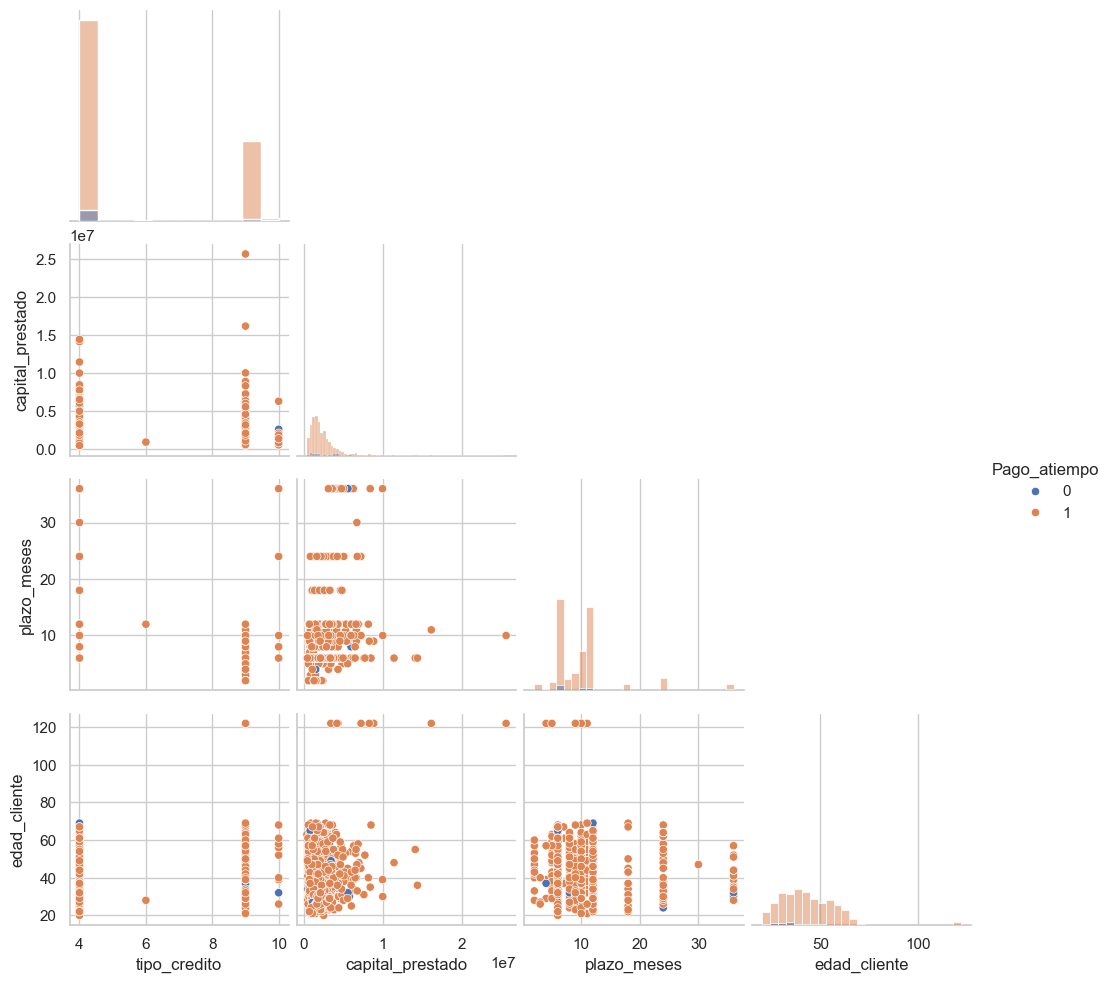

In [15]:
# Seleccionamos pocas variables para pairplot y evitar sobrecarga visual
pairplot_cols = [c for c in numeric_without_target[:4] if c in df_supervised.columns]

# Incluimos objetivo para colorear cuando existan suficientes columnas
if pairplot_cols:
    pairplot_data = df_supervised[pairplot_cols + [target_col]].dropna()

    # Muestreamos para acelerar render si hay muchos registros
    sample_size = min(800, len(pairplot_data))
    pairplot_sample = pairplot_data.sample(sample_size, random_state=42) if sample_size > 0 else pairplot_data

    sns.pairplot(pairplot_sample, hue=target_col, corner=True, diag_kind="hist")
    plt.show()

## 9.1 Visualizacion de posible colinealidad con scatter plots

Complementamos el heatmap con graficas de dispersion para los pares numericos mas correlacionados.

Objetivo:
- Ver relacion lineal/no lineal entre variables.
- Detectar redundancia visual y clusters.
- Confirmar si la correlacion observada en la matriz se mantiene en la nube de puntos.

Pares mostrados (|corr| >= 0.5): 6


,var_x,var_y,abs_corr
131,cant_creditosvigentes,creditos_sectorFinanciero,0.791253
22,capital_prestado,cuota_pactada,0.764104
150,saldo_total,saldo_principal,0.734664
66,salario_cliente,total_otros_prestamos,0.596990
133,cant_creditosvigentes,creditos_sectorReal,0.540677
157,saldo_principal,creditos_sectorFinanciero,0.537307


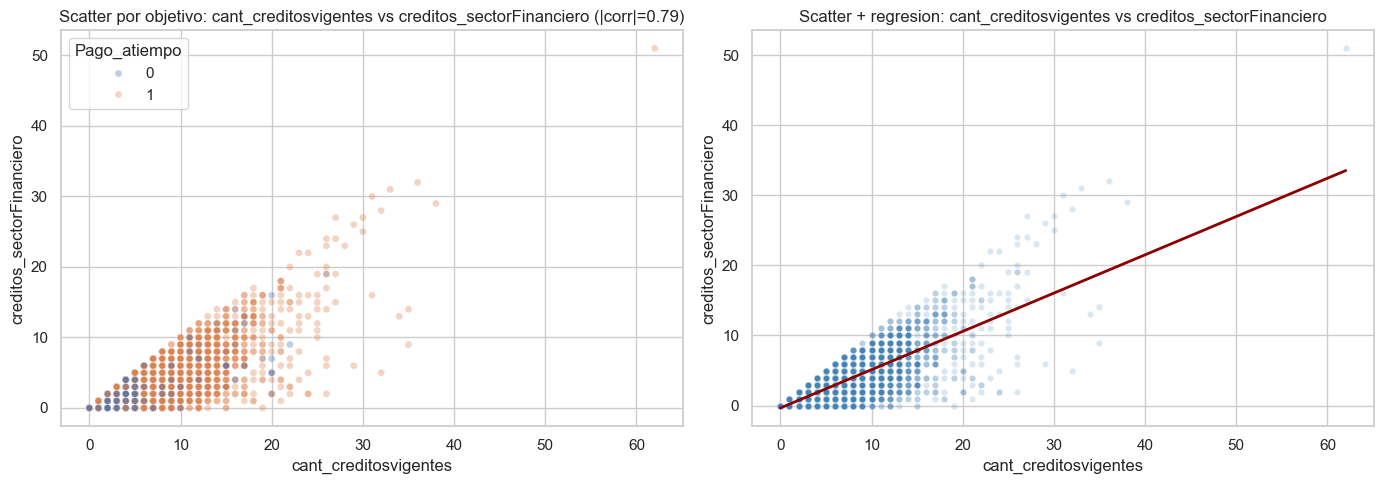

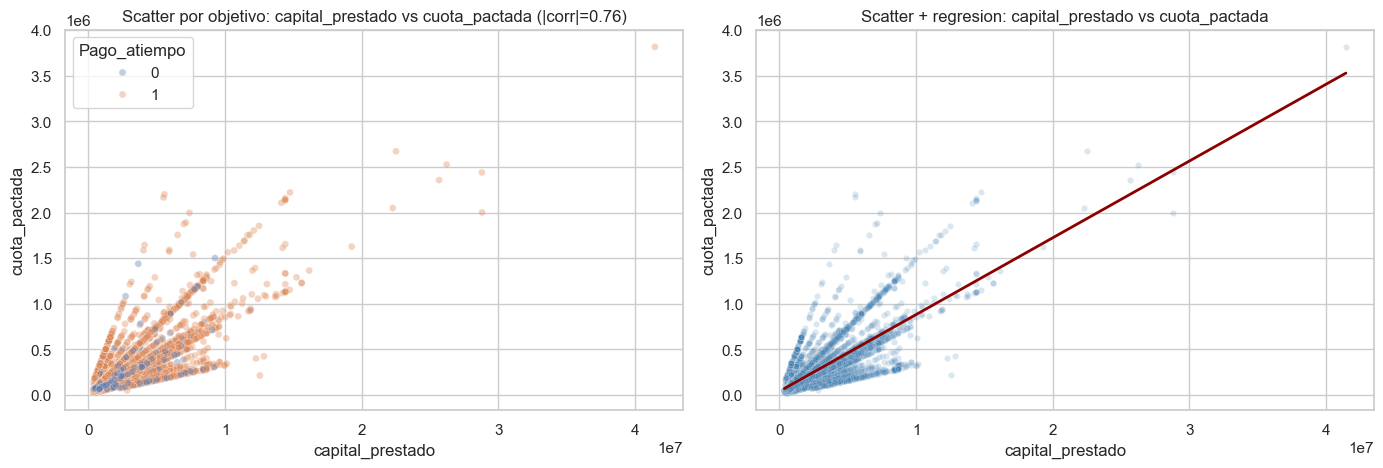

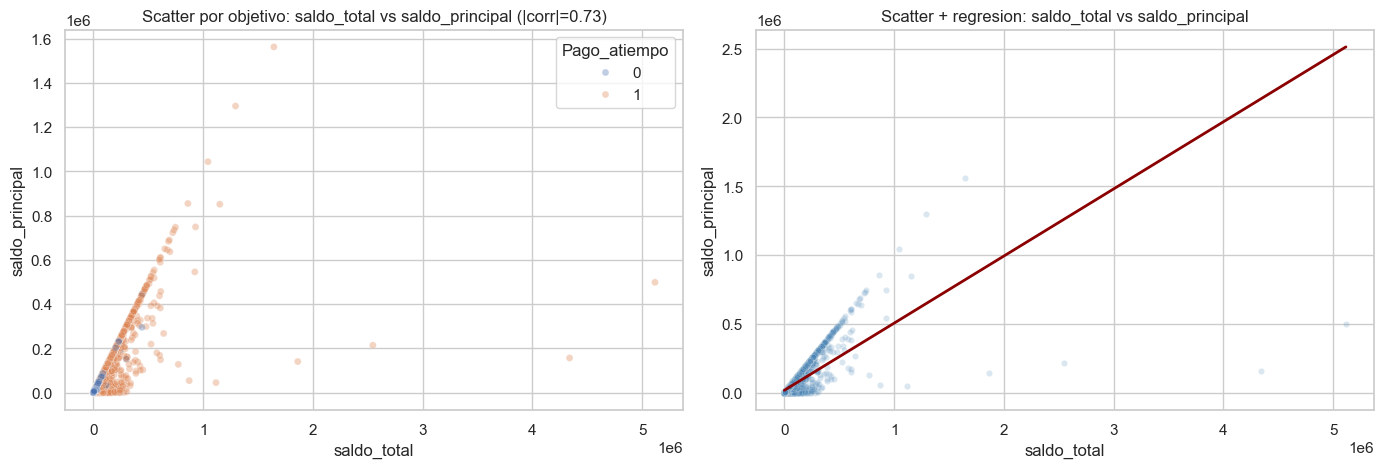

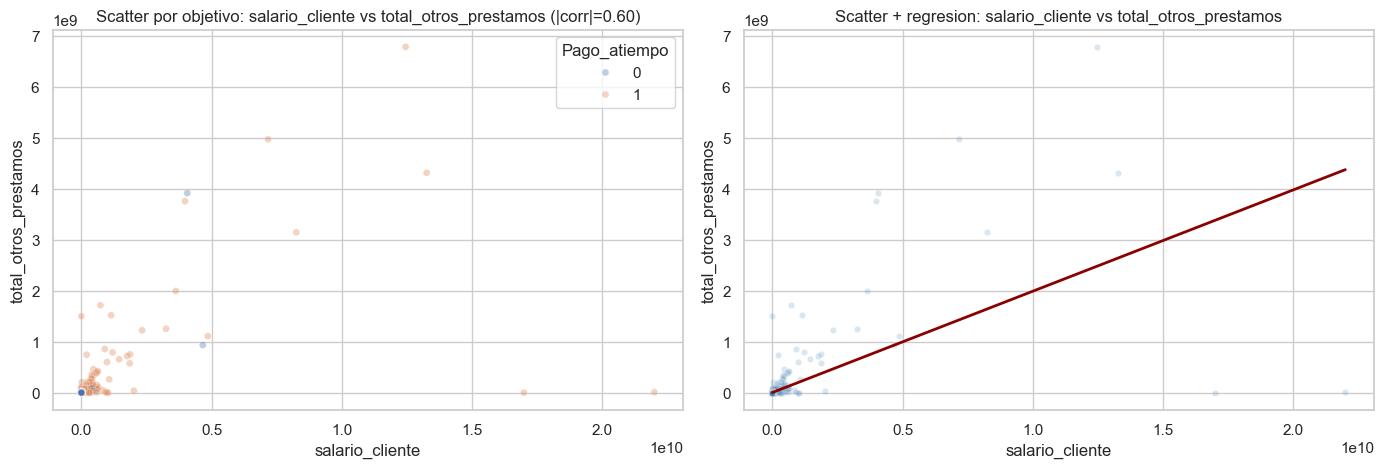

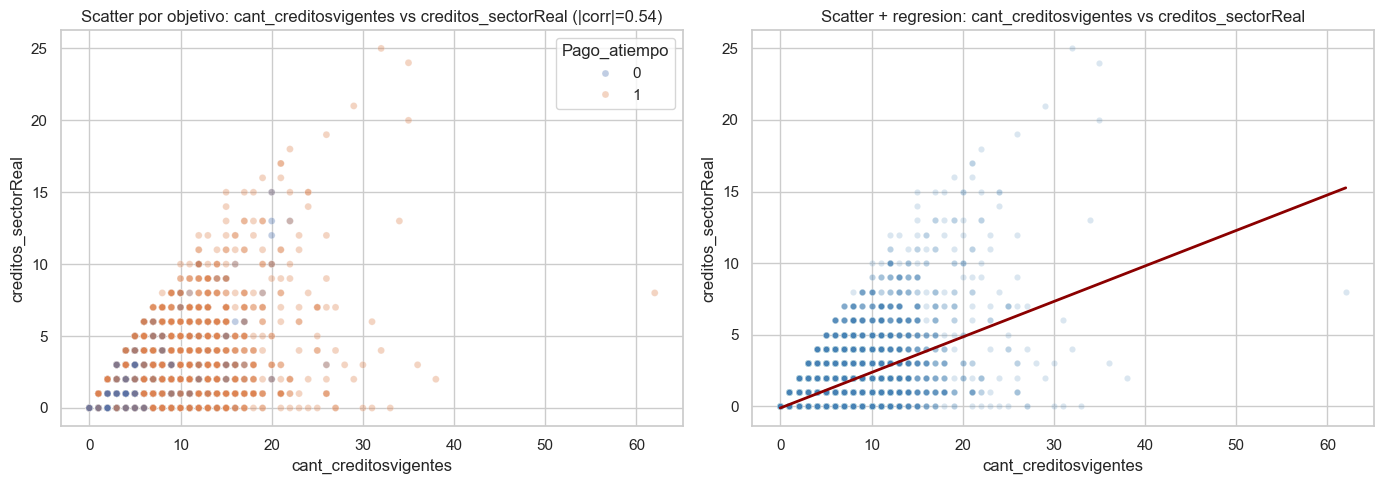

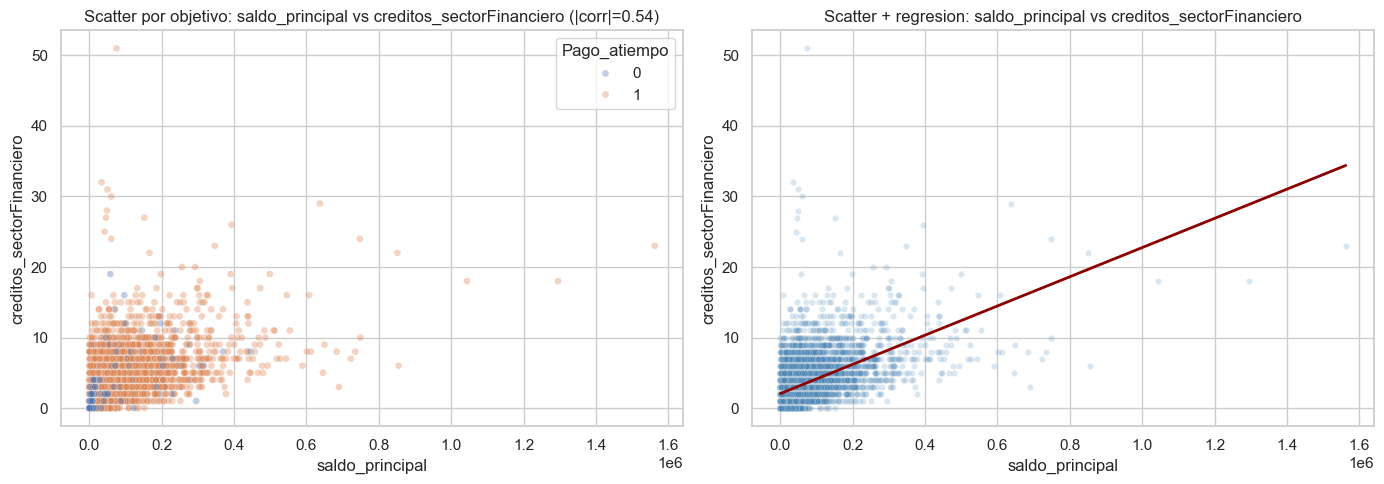

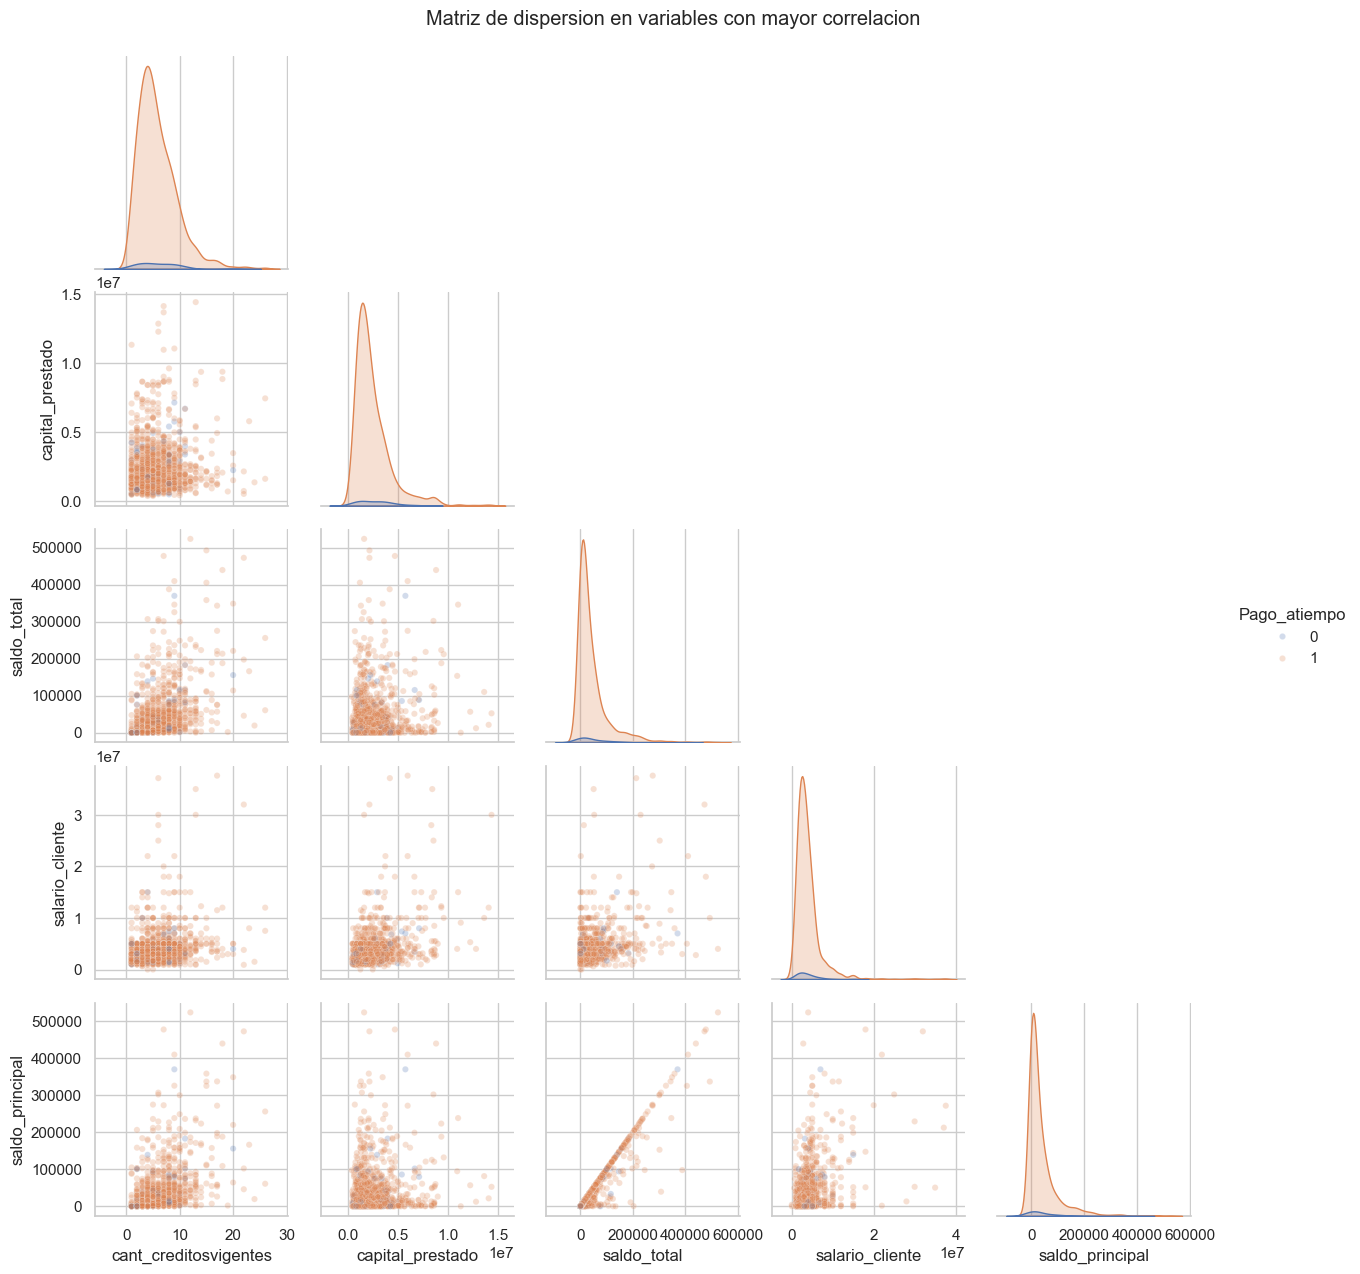

In [16]:
# Recalculamos listas minimas por robustez si el usuario ejecuta celdas fuera de orden
numeric_cols_local = df.select_dtypes(include=["number"]).columns.tolist()
numeric_without_target_local = [c for c in numeric_cols_local if c != target_col]

df_supervised_local = df[df[target_col].notna()].copy()

# Matriz de correlacion absoluta para detectar pares mas asociados
corr_abs = df_supervised_local[numeric_without_target_local].corr(numeric_only=True).abs()
upper_abs = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Tabla de pares ordenados por mayor correlacion absoluta
top_pairs = (
    upper_abs
    .stack()
    .reset_index()
    .rename(columns={"level_0": "var_x", "level_1": "var_y", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)

# Filtramos pares suficientemente correlacionados y tomamos los mas relevantes
corr_threshold = 0.5
top_pairs_filtered = top_pairs[top_pairs["abs_corr"] >= corr_threshold].head(6)

print(f"Pares mostrados (|corr| >= {corr_threshold}): {len(top_pairs_filtered)}")
display(top_pairs_filtered)

# Si no hay pares sobre umbral, usamos igualmente los top 4 para inspeccion visual
pairs_to_plot = top_pairs_filtered if not top_pairs_filtered.empty else top_pairs.head(4)

for _, row in pairs_to_plot.iterrows():
    x_col = row["var_x"]
    y_col = row["var_y"]
    corr_value = row["abs_corr"]

    # Dataset limpio para el par actual
    pair_df = df_supervised_local[[x_col, y_col, target_col]].dropna()

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter por clase objetivo para ver separacion y densidad
    sns.scatterplot(
        data=pair_df,
        x=x_col,
        y=y_col,
        hue=target_col,
        alpha=0.35,
        s=25,
        ax=ax[0],
    )
    ax[0].set_title(f"Scatter por objetivo: {x_col} vs {y_col} (|corr|={corr_value:.2f})")

    # Scatter + recta de regresion global para evaluar tendencia lineal
    sns.scatterplot(
        data=pair_df,
        x=x_col,
        y=y_col,
        alpha=0.2,
        s=20,
        color="steelblue",
        ax=ax[1],
    )
    sns.regplot(
        data=pair_df,
        x=x_col,
        y=y_col,
        scatter=False,
        ci=None,
        line_kws={"color": "darkred", "linewidth": 2},
        ax=ax[1],
    )
    ax[1].set_title(f"Scatter + regresion: {x_col} vs {y_col}")

    plt.tight_layout()
    plt.show()

# Matriz de dispersion enfocada en variables de mayor colinealidad
vars_for_matrix = pd.unique(
    pairs_to_plot[["var_x", "var_y"]].values.ravel("K")
).tolist()

# Acotamos para mantener la visualizacion legible
vars_for_matrix = vars_for_matrix[:5]

if vars_for_matrix:
    matrix_df = df_supervised_local[vars_for_matrix + [target_col]].dropna()
    sample_size = min(1200, len(matrix_df))
    matrix_sample = matrix_df.sample(sample_size, random_state=42) if sample_size > 0 else matrix_df

    sns.pairplot(
        matrix_sample,
        vars=vars_for_matrix,
        hue=target_col,
        corner=True,
        diag_kind="kde",
        plot_kws={"alpha": 0.25, "s": 20},
    )
    plt.suptitle("Matriz de dispersion en variables con mayor correlacion", y=1.02)
    plt.show()

## 10. Reglas de validacion propuestas para etapa posterior
Derivamos reglas iniciales de calidad para automatizar controles del dataset en el pipeline.

In [17]:
# Definimos reglas base de validacion por negocio y por estadistica
validation_rules = {
    "edad_cliente": {"min": 18, "max": 90},
    "plazo_meses": {"min": 1, "max": 120},
    "capital_prestado": {"min": 0},
    "salario_cliente": {"min": 0},
    "Pago_atiempo": {"allowed": [0, 1]} if "Pago_atiempo" in df.columns else {},
}

# Convertimos reglas en tabla para documentacion y futura automatizacion
rules_df = pd.DataFrame(validation_rules).T
display(rules_df)

# Medimos outliers por regla IQR para numericas, util en monitoreo de calidad
outlier_report = []
for col in numeric_without_target:
    s = df[col].dropna()
    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append({
        "variable": col,
        "limite_inf_iqr": lower,
        "limite_sup_iqr": upper,
        "cantidad_outliers": int(outliers),
        "pct_outliers": round(outliers / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("pct_outliers", ascending=False)
display(outlier_df)

,min,max,allowed
edad_cliente,18.0,90.0,NaN
plazo_meses,1.0,120.0,NaN
capital_prestado,0.0,NaN,NaN
salario_cliente,0.0,NaN,NaN
Pago_atiempo,NaN,NaN,"[0, 1]"


,variable,limite_inf_iqr,limite_sup_iqr,cantidad_outliers,pct_outliers
16,creditos_sectorCooperativo,0.000000e+00,0.000000e+00,1895,17.61
7,puntaje,9.522779e+01,9.522779e+01,1356,12.60
12,saldo_total,-7.222800e+04,1.281080e+05,970,9.01
13,saldo_principal,-6.472338e+04,1.150456e+05,951,8.84
2,plazo_meses,-3.000000e+00,2.100000e+01,869,8.07
18,promedio_ingresos_datacredito,-1.034896e+06,4.191912e+06,784,7.28
6,cuota_pactada,-1.291465e+05,5.380215e+05,765,7.11
4,salario_cliente,-2.313712e+06,9.189520e+06,718,6.67
5,total_otros_prestamos,-1.750000e+06,4.250000e+06,589,5.47
1,capital_prestado,-1.565182e+06,5.874854e+06,550,5.11


## 11. Atributos derivados y transformaciones candidatas
Creamos variables potenciales y documentamos transformaciones que podrian mejorar el modelado.

In [18]:
# Trabajamos sobre una copia para no alterar el DataFrame base del EDA
df_features = df.copy()

# Derivamos ratio deuda/ingreso cuando existan columnas necesarias
if {"total_otros_prestamos", "salario_cliente"}.issubset(df_features.columns):
    df_features["ratio_deuda_ingreso"] = np.where(
        df_features["salario_cliente"] > 0,
        df_features["total_otros_prestamos"] / df_features["salario_cliente"],
        np.nan
    )

# Derivamos esfuerzo de cuota sobre ingreso
if {"cuota_pactada", "salario_cliente"}.issubset(df_features.columns):
    df_features["ratio_cuota_ingreso"] = np.where(
        df_features["salario_cliente"] > 0,
        df_features["cuota_pactada"] / df_features["salario_cliente"],
        np.nan
    )

# Extraemos componentes temporales de la fecha del prestamo
if "fecha_prestamo" in df_features.columns:
    df_features["anio_prestamo"] = df_features["fecha_prestamo"].dt.year
    df_features["mes_prestamo"] = df_features["fecha_prestamo"].dt.month
    df_features["dia_semana_prestamo"] = df_features["fecha_prestamo"].dt.dayofweek

# Mostramos muestra de nuevas variables para validar calculo
derived_cols = [c for c in ["ratio_deuda_ingreso", "ratio_cuota_ingreso", "anio_prestamo", "mes_prestamo", "dia_semana_prestamo"] if c in df_features.columns]
display(df_features[derived_cols].head())

# Lista de transformaciones candidatas para siguiente etapa
transformaciones_candidatas = [
    "Imputacion de nulos por mediana (numericas) y moda (categoricas)",
    "Escalado robusto para variables con outliers",
    "Codificacion one-hot para categoricas nominales",
    "Transformacion logaritmica en variables altamente sesgadas",
    "Agrupacion de categorias poco frecuentes",
]

for t in transformaciones_candidatas:
    print(f"- {t}")

,ratio_deuda_ingreso,ratio_cuota_ingreso,anio_prestamo,mes_prestamo,dia_semana_prestamo
0,0.312500,0.042662,2024,12,5
1,0.666667,0.041625,2025,4,1
2,0.205401,0.131208,2026,1,3
3,0.326654,0.165570,2025,8,0
4,0.800000,0.043407,2025,4,5


- Imputacion de nulos por mediana (numericas) y moda (categoricas)
- Escalado robusto para variables con outliers
- Codificacion one-hot para categoricas nominales
- Transformacion logaritmica en variables altamente sesgadas
- Agrupacion de categorias poco frecuentes


## 12. Conclusiones EDA

- Se estandarizo la representacion de nulos y tipos de dato por columna.
- Se generaron metricas uni/bi/multivariable para entender la estructura del dataset.
- Se propusieron reglas de validacion para control de calidad en etapas posteriores.
- Se identificaron variables derivadas y transformaciones candidatas para modelado.

Con este resultado, el dataset queda listo para la etapa de preparacion de features y entrenamiento.